        fecha  ayacucho  caicara  ciudad_bolivar  palua  \
0  1981-01-01     42.54    26.04            6.00   2.76   
1  1981-01-02     42.60    26.02            5.88   2.55   
2  1981-01-03     42.64    26.00            5.80   2.50   
3  1981-01-04     42.65    25.98            5.76   2.44   
4  1981-01-05     42.65    25.96            5.71   2.25   

   precipitacion_mm_ciudad_bolivar  temp_media_c_ciudad_bolivar  \
0                             0.00                        25.13   
1                             0.69                        25.45   
2                             0.90                        25.63   
3                             0.66                        24.91   
4                             2.33                        25.32   

   humedad_especifica_ciudad_bolivar  humedad_suelo_ciudad_bolivar  \
0                              15.34                          0.51   
1                              16.01                          0.50   
2                              1

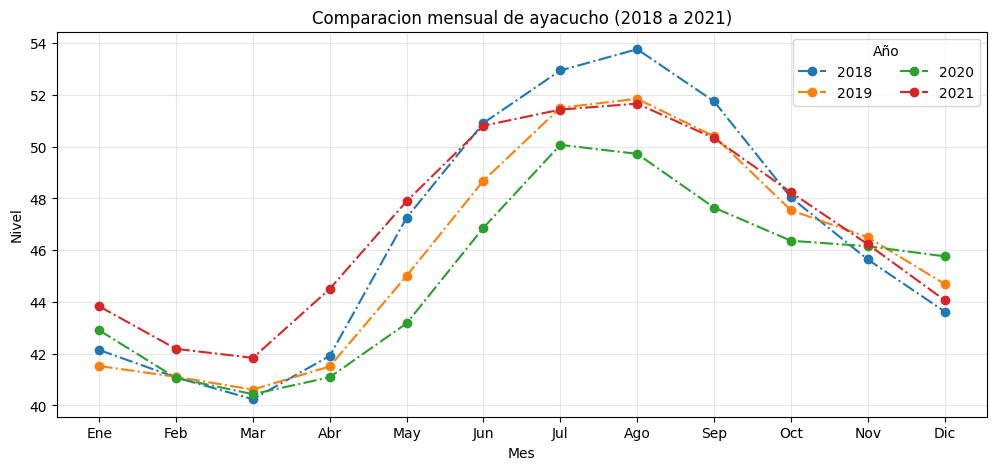

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv", sep=",")

print(df.head())

df.columns = df.columns.str.strip()
df["fecha"] = pd.to_datetime(df["fecha"], format="%Y-%m-%d", errors="coerce")

col_valor = "ayacucho"
anio_inicio = 2018
anio_fin = 2021

meses = list(range(1, 13))
nombres_meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

plt.figure(figsize=(12, 5))

for anio in range(anio_inicio, anio_fin + 1):
    s = (
        df[df["fecha"].dt.year == anio]
        .groupby(df["fecha"].dt.month)[col_valor]
        .mean()
        .reindex(meses)
    )
    plt.plot(meses, s, marker="o", label=str(anio), linestyle="-.")

plt.xticks(meses, nombres_meses)
plt.xlabel("Mes")
plt.ylabel("Nivel")
plt.title(f"Comparacion mensual de {col_valor} ({anio_inicio} a {anio_fin})")
plt.grid(True, alpha=0.3)
plt.legend(title="Año", ncol=2)
plt.show()